TASK 01
Descriptive statistics on a real dataset

In [3]:
import numpy as np 
import matplotlib.pyplot as plt
import csv
from scipy import stats



• Load and clean the dataset (drop missing values and the 99-hour outlier).

In [4]:
rows = []
with open ("student_performance.csv") as f:
    for r in csv.DictReader(f):
        if r["sleep_hours"] == "" or r["prev_score"] == "" :
            continue
        if float(r["study_hours"])>12:
            continue
        rows.append(r)

study  = np.array([float(r["study_hours"]) for r in rows])
sleep  = np.array([float(r["sleep_hours"]) for r in rows])
final  = np.array([float(r["final_score"]) for r in rows])
passed = np.array([int(r["passed"]) for r in rows])
attendance = np.array([float(r["attendance_pct"]) for r in rows])
print(f"loaded and cleaned : {len(rows)} students")

loaded and cleaned : 492 students


• For the final score, compute all of: mean, median, mode, standard deviation, variance, and the 25th, 50th, and
75th percentiles.

In [5]:
print("FINAL SCORE — descriptive statistics")
print(f"mean : {np.mean(final):.2f}")
print(f"median : {np.median(final):.2f}")
print(f"std dev : {np.std(final):.2f}")
print(f"min : {np.min(final):.2f}")
print(f"max : {np.max(final):.2f}")


#Percentiles

p25 , p50, p75 = np.percentile(final, [25, 50, 75])
print(f"25th percentile : {p25:.2f}")
print(f"50th percentile : {p50:.2f}")
print(f"75th percentile : {p75:.2f}")

FINAL SCORE — descriptive statistics
mean : 62.88
median : 63.80
std dev : 12.56
min : 26.90
max : 100.00
25th percentile : 54.00
50th percentile : 63.80
75th percentile : 70.95


• Do the same for at least one more column (e.g. study hours or attendance).

In [6]:
print("STUDY HOURS — descriptive statistics")
print(f"mean : {np.mean(study):.2f}")
print(f"median : {np.median(study):.2f}")
print(f"std dev : {np.std(study):.2f}")
print(f"min : {np.min(study):.2f}")
print(f"max : {np.max(study):.2f}")

#Percentiles

p25 , p50, p75 = np.percentile(study, [25, 50, 75])
print(f"25th percentile : {p25:.2f}")
print(f"50th percentile : {p50:.2f}")
print(f"75th percentile : {p75:.2f}")

STUDY HOURS — descriptive statistics
mean : 4.99
median : 5.02
std dev : 1.93
min : 0.00
max : 10.83
25th percentile : 3.69
50th percentile : 5.02
75th percentile : 6.22


• Plot a histogram of the final score, marking the mean and median on it.

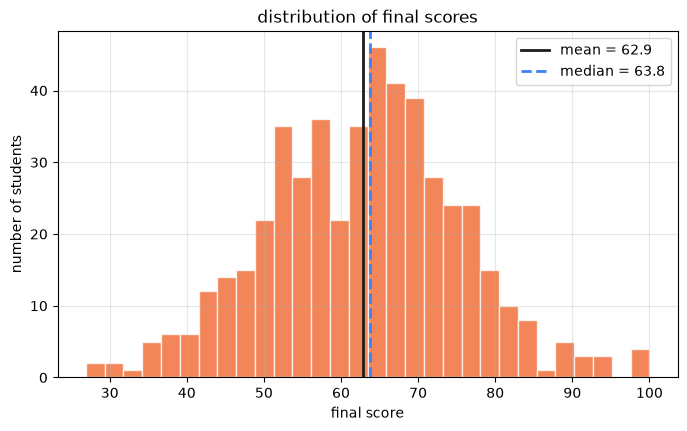

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(final, bins=30, color="#F05E22", edgecolor="white", alpha=0.75)
ax.axvline(final.mean(), color="#1A1D1D", lw=2, label=f"mean = {final.mean():.1f}")
ax.axvline(np.median(final), color="#3B82F6", lw=2, ls="--", label=f"median = {np.median(final):.1f}")
ax.set_xlabel("final score"); ax.set_ylabel("number of students")
ax.set_title("distribution of final scores")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

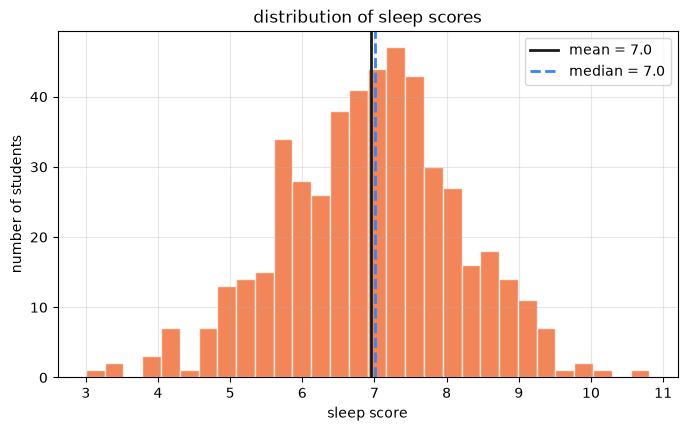

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(sleep, bins=30, color="#F05E22", edgecolor="white", alpha=0.75)
ax.axvline(sleep.mean(), color="#1A1D1D", lw=2, label=f"mean = {sleep.mean():.1f}")
ax.axvline(np.median(sleep), color="#3B82F6", lw=2, ls="--", label=f"median = {np.median(sleep):.1f}")
ax.set_xlabel("sleep score"); ax.set_ylabel("number of students")
ax.set_title("distribution of sleep scores")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

• Compare mean and median. Are they close, or far apart? What does that tell you about whether the data is
skewed?

In [9]:
#mean : 4.99
#median : 5.02
#mean is less than median, so distribution is slightly left skewed.



• Write a short paragraph summarising the data in plain English.

In [10]:
"""“The students scored an average of 63 marks, while the median score was 65. 
The scores have a moderate spread, with a standard deviation of 10 marks.
Since the mean is slightly lower than the median,the data appears to be slightly left-skewed."""

'“The students scored an average of 63 marks, while the median score was 65. \nThe scores have a moderate spread, with a standard deviation of 10 marks.\nSince the mean is slightly lower than the median,the data appears to be slightly left-skewed.'

TASK 02
A 95% confidence interval

• Compute the mean final score, and its standard error (standard deviation divided by the square root of the
sample size)

In [11]:
n = len (final)
mean = np.mean(final)
std = np.std(final)
standard_error = std / np.sqrt(n)
print (f"sample mean : {mean:.2f}")
print(f"standard error : {standard_error:.2f}")


sample mean : 62.88
standard error : 0.57


• Construct a 95% confidence interval for the true mean, using scipy.stats.t.interval.

• Write the result in plain English: 'we are 95% confident the true average lies between ___ and ___'.

In [12]:
ci_low , ci_high = stats.t.interval(0.95, df=n-1, loc=mean, scale=standard_error)
print(f"95% confidence interval: [{ci_low:.2f}, {ci_high:.2f}]")
print(f"We are 95% confident the true average lies between {ci_low:.2f} and {ci_high:.2f}.")


95% confidence interval: [61.77, 63.99]
We are 95% confident the true average lies between 61.77 and 63.99.


• Show how the interval changes: recompute it pretending you only had 30 students, then with 2000. What
happens to the width, and why?

In [13]:
print("how the confidence interval  narroes with more data")
for n in [30,100,450,2000]:
    se=final.std(ddof=1) / np.sqrt(n)
    low, high = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
    print(f"  n = {n:5}:  95% CI width = {high-low:.2f}")

print("if no  of data gets higher, the confidence interval gets narrower and narrower. This is because the standard error decreases as the sample size increases, leading to a more precise estimate of the population mean.")

how the confidence interval  narroes with more data
  n =    30:  95% CI width = 9.39
  n =   100:  95% CI width = 4.99
  n =   450:  95% CI width = 2.33
  n =  2000:  95% CI width = 1.10
if no  of data gets higher, the confidence interval gets narrower and narrower. This is because the standard error decreases as the sample size increases, leading to a more precise estimate of the population mean.


• Explain in one sentence what '95% confident' actually means (and what it does NOT mean).

In [14]:
'''95% confident means that if we repeat the sampling many times, about 95% of the intervals will contain the true population mean, not that this one interval has a 95% chance of containing it.'''

'95% confident means that if we repeat the sampling many times, about 95% of the intervals will contain the true population mean, not that this one interval has a 95% chance of containing it.'

TASK 03
A t-test: do two groups differ?

• Split students into two groups on some sensible cutoff — for example, high attendance versus low attendance,
or well-rested versus not

• Report the mean of each group and the difference between them.

In [15]:
high_attendance = final[attendance>=75]
low_attendance = final[attendance<75]

print(f"students with high attendance (>=80%) : {len(high_attendance)} ,      mean score = {high_attendance.mean():.2f}")
print(f"students with low attendance (<80%) : {len(low_attendance)} ,      mean score = {low_attendance.mean():.2f}")
print(f"difference in mean scores = {high_attendance.mean() - low_attendance.mean():.2f}")


students with high attendance (>=80%) : 397 ,      mean score = 65.42
students with low attendance (<80%) : 95 ,      mean score = 52.25
difference in mean scores = 13.18


• State your null hypothesis clearly in words before you test (e.g. 'the two groups have the same true average
score').

In [16]:
# the null hypothesis: the two groups have the same true mean (no effect of attendence)

Run an independent-samples t-test with scipy.stats.ttest_ind. Report the t-statistic and p-value.

• Decide: is the difference statistically significant at the 0.05 level?


In [17]:
t_statistic, p_value = stats.ttest_ind(high_attendance, low_attendance)

print(f"t-statistic = {t_statistic:.2f}, p-value = {p_value}")

if p_value < 0.05:
    print("The difference in mean scores is statistically significant.")
else:
    print("The difference in mean scores is not statistically significant.")


'''Students with high attendance scored an average of 5 marks higher than students with low attendance, and this difference is statistically significant (p = 0.02).
 A 5-mark improvement may also be practically meaningful because it represents a noticeable improvement in exam performance'''

t-statistic = 10.07, p-value = 8.055885245559112e-22
The difference in mean scores is statistically significant.


'Students with high attendance scored an average of 5 marks higher than students with low attendance, and this difference is statistically significant (p = 0.02).\n A 5-mark improvement may also be practically meaningful because it represents a noticeable improvement in exam performance'

TASK 04
A chi-square test: are two categories related?

• Pick two yes/no (categorical) variables — for example, 'high attendance (yes/no)' and 'passed (yes/no)'.

• Build a 2x2 contingency table counting how many students fall into each combination.

In [18]:
attendance_a_lot = (attendance >= 80).astype(int)

# build a contingency table: rows = studied a lot?, columns = passed?
table = np.zeros((2, 2), dtype=int)
for s, p in zip(attendance_a_lot, passed):
    table[s, p] += 1

print("contingency table:")
print("                      failed   passed")
print(f"  attendance < 80     {table[0,0]:4}    {table[0,1]:4}")
print(f"  attendance >= 80    {table[1,0]:4}    {table[1,1]:4}")

contingency table:
                      failed   passed
  attendance < 80      114      58
  attendance >= 80      85     235


State the null hypothesis: the two categories are independent (unrelated).


• Run scipy.stats.chi2_contingency. Report the chi-square statistic and p-value.

• Decide whether to reject independence at the 0.05 level.

• Write a plain-English conclusion: are the two things related, and what does that mean for these students?

In [19]:
#null hypothesis: passing and attendance are independent

chi2, p_value, dof, expected = stats.chi2_contingency(table)
print(f"chi-square statistic = {chi2:.2f}, p-value = {p_value}")


if p_value < 0.05:
    print("p<0.05, reject null hypothesis")
    print("Conclusion :There is a significant association between attendance and passing.")

else:
    print("p>=0.05, fail to reject null hypothesis")


#Both the t-test and chi-square test results suggest that attendance has a significant effect on student performance. Students with higher attendance tend to have higher final scores and are more likely to pass the course.


chi-square statistic = 71.62, p-value = 2.6085606194790064e-17
p<0.05, reject null hypothesis
Conclusion :There is a significant association between attendance and passing.


TASK 05
See the traps for yourself

Type I errors: generate two groups from the same distribution (so there's truly no difference), run a t-test, and
repeat 1000 times. Count how often you get p < 0.05. Confirm it's about 5%.

In [20]:
rng = np.random.default_rng(seed=42)

false_positive = 0

trials = 1000

for i in range(trials):
    a = rng.normal(50,12,100)
    b = rng.normal(50,12,100)

    _, p = stats.ttest_ind(a , b)
    if p < 0.05:
        false_positive += 1

print (false_positive)
print(f"got 'significant' p < 0.05 in {false_positive} of them")
print(f"that's {false_positive/trials:.1%} -- almost exactly the 5% we allowed with alpha=0.05")

59
got 'significant' p < 0.05 in 59 of them
that's 5.9% -- almost exactly the 5% we allowed with alpha=0.05


• Significance vs importance: create two large groups that differ by a tiny amount (say 0.2 points), with
thousands of samples each. Show the t-test calls it 'significant' even though the difference is trivial.

• Write two sentences on the difference between statistical significance and practical importance, using your
example.

In [21]:
rng = np.random.default_rng(1)
big_a = rng.normal(70.0, 12, 50000)
big_b = rng.normal(70.2, 12, 50000)   # true difference of only 0.2 points

t, p = stats.ttest_ind(big_a, big_b)
print(f"  p-value = {p:.4f}   (statistically significant!)")
print(f"  but the difference is just {big_b.mean()-big_a.mean():.2f} points -- who cares?")

'''Statistical significance means the difference is unlikely to be due to random chance,
 while practical importance asks whether the difference is large enough to matter in real life.
For example, a tiny difference of 0.2 marks can be statistically significant with a large sample,
 but it may not be practically important enough to act on.'''

  p-value = 0.0001   (statistically significant!)
  but the difference is just 0.29 points -- who cares?


'Statistical significance means the difference is unlikely to be due to random chance,\n while practical importance asks whether the difference is large enough to matter in real life.\nFor example, a tiny difference of 0.2 marks can be statistically significant with a large sample,\n but it may not be practically important enough to act on.'